# Spectral Analysis (Simple View)

This notebook uses the same aggregated signal extraction as `notebooks/spectral_analysis_big.ipynb`, but keeps visualization minimal:

- Graph 1: Signal A + baseline A
- Graph 2: Signal B + baseline B

No IQR bands and no extra normalization chart.

In [1]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

MAX_RUNS = 1000
INCLUDE_BASELINE = True
RANDOM_SEED = 7


def find_repo_root() -> Path:
    cwd = Path.cwd()
    candidates = [cwd, *cwd.parents]
    for candidate in candidates:
        if (candidate / "analysis_out").exists():
            return candidate
    return cwd


def to_int_float_map(d):
    return {int(k): float(v) for k, v in (d or {}).items()}


def collect_spectral_entries(payload: dict, run_path: Path, include_baseline: bool = True):
    entries = []

    if include_baseline:
        baseline = payload.get("baseline_spectral", payload.get("baseline_spectral_bin", {}))
        a_map = to_int_float_map(baseline.get("sv_z_scores", {}))
        b_map = to_int_float_map(baseline.get("sv_ratio_scores", {}))
        if a_map:
            entries.append(
                {
                    "source": "baseline",
                    "run_file": run_path.name,
                    "case_id": "baseline",
                    "a_map": a_map,
                    "b_map": b_map,
                }
            )

    for test in payload.get("tests", []):
        if test.get("skipped", False):
            continue
        block = test.get("spectral_detection", test.get("spectral_bin_detection", {}))
        a_map = to_int_float_map(block.get("sv_z_scores", {}))
        b_map = to_int_float_map(block.get("sv_ratio_scores", {}))
        if not a_map:
            continue
        entries.append(
            {
                "source": "test",
                "run_file": run_path.name,
                "case_id": test.get("case_id", "N/A"),
                "a_map": a_map,
                "b_map": b_map,
            }
        )

    return entries

In [2]:
ROOT = find_repo_root()
ANALYSIS_DIR = ROOT / "analysis_out"
run_files = sorted(ANALYSIS_DIR.glob("*.json"), key=lambda p: p.stat().st_mtime, reverse=True)

all_entries = []
for run_path in run_files:
    try:
        with open(run_path, "r") as f:
            payload = json.load(f)
        all_entries.extend(collect_spectral_entries(payload, run_path, include_baseline=INCLUDE_BASELINE))
    except Exception:
        continue

if not all_entries:
    raise ValueError(f"No spectral entries found under {ANALYSIS_DIR}")

if len(all_entries) > MAX_RUNS:
    rng = np.random.default_rng(RANDOM_SEED)
    keep_idx = rng.choice(len(all_entries), size=MAX_RUNS, replace=False)
    entries = [all_entries[i] for i in sorted(keep_idx)]
else:
    entries = all_entries

baseline_entries = [entry for entry in entries if entry["source"] == "baseline"]

all_layers = sorted(
    set().union(*[set(entry["a_map"].keys()) for entry in entries], *[set(entry["b_map"].keys()) for entry in entries if entry["b_map"]])
)

n_runs = len(entries)
n_layers = len(all_layers)

a_matrix = np.full((n_runs, n_layers), np.nan)
b_matrix = np.full((n_runs, n_layers), np.nan)

for i, entry in enumerate(entries):
    for j, layer in enumerate(all_layers):
        a_matrix[i, j] = entry["a_map"].get(layer, np.nan)
        b_matrix[i, j] = entry["b_map"].get(layer, np.nan)

layers = all_layers
a_values = np.nanmedian(a_matrix, axis=0)
b_values = np.nanmedian(b_matrix, axis=0)

a_q25, a_q75 = np.nanpercentile(a_matrix, [25, 75], axis=0)
if np.isfinite(b_matrix).any():
    b_q25, b_q75 = np.nanpercentile(b_matrix, [25, 75], axis=0)
else:
    b_q25 = np.full_like(b_values, np.nan)
    b_q75 = np.full_like(b_values, np.nan)

if baseline_entries:
    base_a_matrix = np.array([[entry["a_map"].get(layer, np.nan) for layer in layers] for entry in baseline_entries], dtype=float)
    baseline_a_values = np.nanmedian(base_a_matrix, axis=0)

    if any(entry["b_map"] for entry in baseline_entries):
        base_b_matrix = np.array([[entry["b_map"].get(layer, np.nan) for layer in layers] for entry in baseline_entries], dtype=float)
        baseline_b_values = np.nanmedian(base_b_matrix, axis=0)
    else:
        baseline_b_values = np.full_like(b_values, np.nan)
else:
    baseline_a_values = np.full_like(a_values, np.nan)
    baseline_b_values = np.full_like(b_values, np.nan)

meta_target_layers = []
for run_path in run_files:
    try:
        with open(run_path, "r") as f:
            payload = json.load(f)
        target_layer = payload.get("metadata", {}).get("target_layer")
        if target_layer is not None:
            meta_target_layers.append(int(target_layer))
    except Exception:
        continue

target_layer_median = int(np.median(meta_target_layers)) if meta_target_layers else None

print(f"JSON files scanned: {len(run_files)}")
print(f"Spectral entries collected: {len(all_entries)}")
print(f"Entries used here: {n_runs} (MAX_RUNS={MAX_RUNS})")
print(f"Baseline entries used: {len(baseline_entries)}")
print(f"Layers in view: {n_layers} ({layers[0]}..{layers[-1]})")
print("Signal source: SAME aggregated extraction as spectral_analysis_big")

JSON files scanned: 11
Spectral entries collected: 311
Entries used here: 311 (MAX_RUNS=1000)
Baseline entries used: 9
Layers in view: 48 (0..47)
Signal source: SAME aggregated extraction as spectral_analysis_big


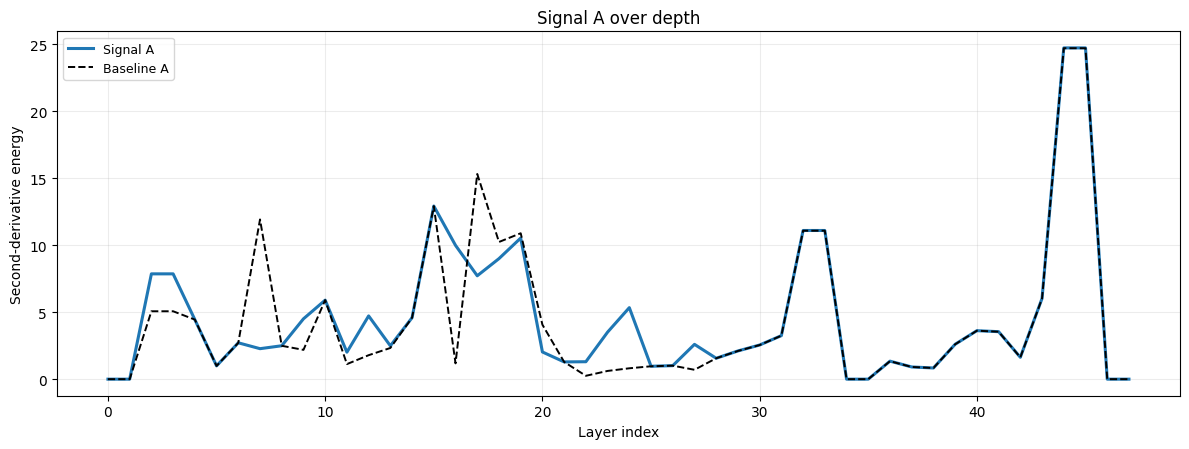

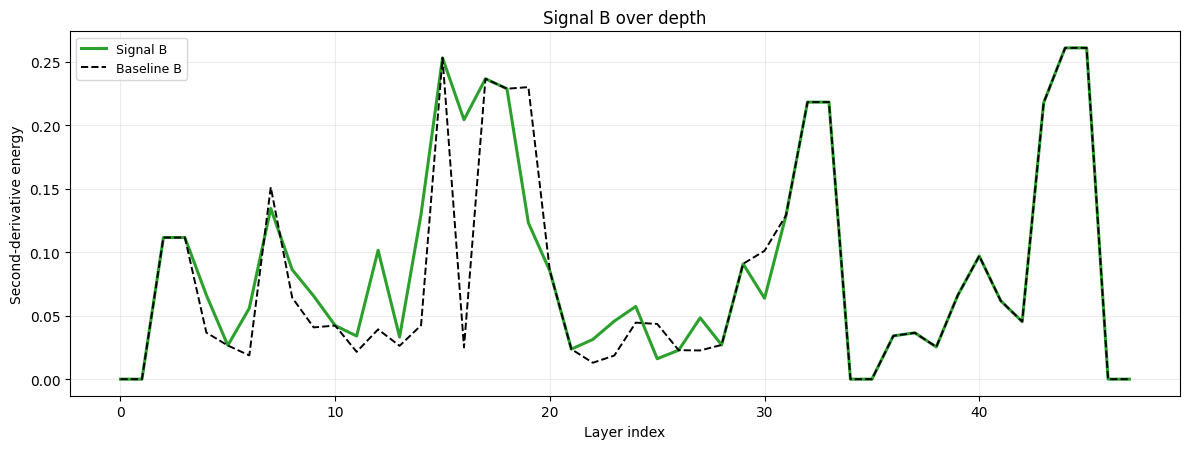

In [3]:
plt.figure(figsize=(12, 4.6))
plt.plot(layers, a_values, color="tab:blue", linewidth=2.2, label="Signal A")
if np.isfinite(baseline_a_values).any():
    plt.plot(layers, baseline_a_values, color="black", linestyle="--", linewidth=1.4, label="Baseline A")
plt.title("Signal A over depth")
plt.xlabel("Layer index")
plt.ylabel("Second-derivative energy")
plt.grid(alpha=0.24)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

if np.isfinite(b_values).any():
    plt.figure(figsize=(12, 4.6))
    plt.plot(layers, b_values, color="tab:green", linewidth=2.2, label="Signal B")
    if np.isfinite(baseline_b_values).any():
        plt.plot(layers, baseline_b_values, color="black", linestyle="--", linewidth=1.4, label="Baseline B")
    plt.title("Signal B over depth")
    plt.xlabel("Layer index")
    plt.ylabel("Second-derivative energy")
    plt.grid(alpha=0.24)
    plt.legend(fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print("No Signal B available.")

In [4]:
print("Simplified view enabled: only Signal A/B with their baselines are plotted above.")

Simplified view enabled: only Signal A/B with their baselines are plotted above.


In [5]:
top_k = 5

def top_layers(layer_ids, values, k=5):
    pairs = [(int(layer), float(val)) for layer, val in zip(layer_ids, values) if np.isfinite(val)]
    pairs.sort(key=lambda item: item[1], reverse=True)
    return pairs[:k]

print(f"Top {top_k} layers by Signal A:")
for layer, score in top_layers(layers, a_values, top_k):
    print(f"  L{layer:02d}: {score:.6f}")

if np.isfinite(b_values).any():
    print(f"\nTop {top_k} layers by Signal B:")
    for layer, score in top_layers(layers, b_values, top_k):
        print(f"  L{layer:02d}: {score:.6f}")
else:
    print("\nSignal B unavailable in this run.")

Top 5 layers by Signal A:
  L44: 24.726316
  L45: 24.726316
  L15: 12.922775
  L32: 11.097397
  L33: 11.097397

Top 5 layers by Signal B:
  L44: 0.260876
  L45: 0.260876
  L15: 0.253024
  L17: 0.236559
  L18: 0.228717
